# Simulated IRFs from True VAR Model

This code creates simulated time series data where the underlying process is an arbitrary VAR model, in order to asses the accuracy of LPs & SPLs when the true process is follows a VAR structure. The underlying VAR model uses randomly generated coefficients and is of order $O$ with $V$ variables. Since all variables are ex-ante identical, only a shock to variable 3 will be considered. For simplicity it is assumed that the econometrician knows the true lag structure.

In [29]:
import sys
sys.path.append("..")

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.api import VAR
from slp.estimators import SmoothLocalProjections
from slp.results import LPResults, SLPResults

# Set seed for reproducibility
np.random.seed(456)

In [ ]:
# Set parameters
O = 4   # VAR order - must be positive
V = 3   # number of variables in VAR - must be greater than 2 since shock is to var3 by default
q = 10  # number of periods for IRF - must be greater than 7 or SLP is poorly conditioned with default smoothing parameter
T = 100 # number of periods for simulated data - must be sufficient for estimation

In [26]:
# Helper function to plot IRFs
def plot_irf_combined(true_irf, var, LP, SLP):
    varnames = ['var1', 'var2', 'var3']
    methods = {
        'True':  (true_irf, 'black',   'o'),
        'VAR':   (var,      'gray', 'D'),
        'LP':    (LP,       '#1565C0', '^'),
        'SLP':   (SLP,      '#DC143C', 's'),
    }
    horizons = range(true_irf.shape[0])
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for i, ax in enumerate(axes):
        for label, (data, color, marker) in methods.items():
            ax.plot(horizons, data.iloc[:, i], color=color, marker=marker,
                    markersize=5, linewidth=1.4, label=label)
        ax.axhline(0, color='black', linestyle='dashed', linewidth=0.8)
        ax.set_title(f'var3 → {varnames[i]}')
        ax.set_xlabel('Periods')
        ax.set_ylabel('Response')
        ax.legend(fontsize=8)
    fig.suptitle('Impulse Response Functions to var3 Shock', fontsize=13)
    plt.tight_layout()
    plt.show()

### Generating observed data

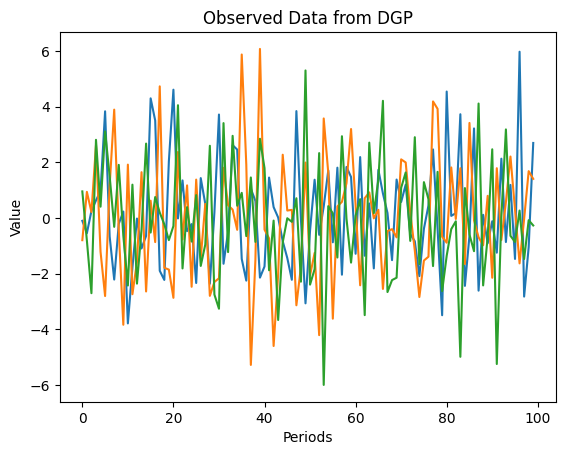

In [4]:
# simulate data from VAR process based on parameters and random coefficients
def VAR_data(V, O, T):

    # check for valid model parameters
    assert O > 0, "VAR order must be positive"
    assert V > 2, "VAR must have 3 or more variables since default shock is to var3"

    A = np.random.uniform(low = -0.25, high = 0.25, size=(O, V, V)) # coefficients restricted to prevent explosive processes
    I = 0.25 * np.ones((O, V)) # initial periods of data

    observed_data = np.zeros((T+O, V))
    for t in range(0, T+O):
        if t < O:
            observed_data[t] = I[t]
        else:
            for o in range(1, O+1):
                observed_data[t] += A[o-1] @ observed_data[t-o, :] + np.random.normal(size = V) # VAR process
    observed_data = pd.DataFrame(observed_data, columns=[f'var{i}' for i in range(1, V+1)])

    observed_data = observed_data.drop(index=range(O)) # drop initial periods of data
    return observed_data.reset_index(drop = True), A

observed_data, A = VAR_data(V,O,T) # save the observed data and the matrices used to generate it (needed for true IRF)

# plot observed time series
plt.plot(observed_data)
plt.title("Observed Data from DGP")
plt.xlabel("Periods")
plt.ylabel("Value")
plt.show()

### Generating true IRFs

In [5]:
# true IRF from for a unit var1 shock
# this is what the econometrician is trying to estimate from observed data
def true(V, O, q, A):
    shock = np.zeros(V)
    shock[2] = 1 # shock variable 3
    irf = np.zeros((q+1, V))
    for t in range(q+1):
        if t == 0:
            irf[t] = shock
        else:
            for o in range(1, O+1):
                if t-o >= 0:
                    irf[t] += A[o-1] @ irf[t-o]

    return pd.DataFrame(irf, columns=[f'var{j}_shock3' for j in range(1, V+1)])

true_irf = true(V,O,q,A)

### Estimating the impulse responses

In [22]:
# VAR estimation of IRFs
var_mod = VAR(observed_data)
var_fit = var_mod.fit(O)
var_irfs = var_fit.irf(periods = q).irfs
var_beta = pd.DataFrame(var_irfs[:,:,2])

# LP/SLP estimation of IRFs
LP_mod = SmoothLocalProjections(observed_data, shock = "var3", endog = None, shock_exo = True, p = O, H = q)
LP_fit = LP_mod.LP()
SLP_fit = LP_mod.SLP(n_knots = 5, lam = 5.0, r = 3)

LP_beta = pd.DataFrame(LP_fit.beta)
SLP_beta = pd.DataFrame(SLP_fit.beta)

### Plots

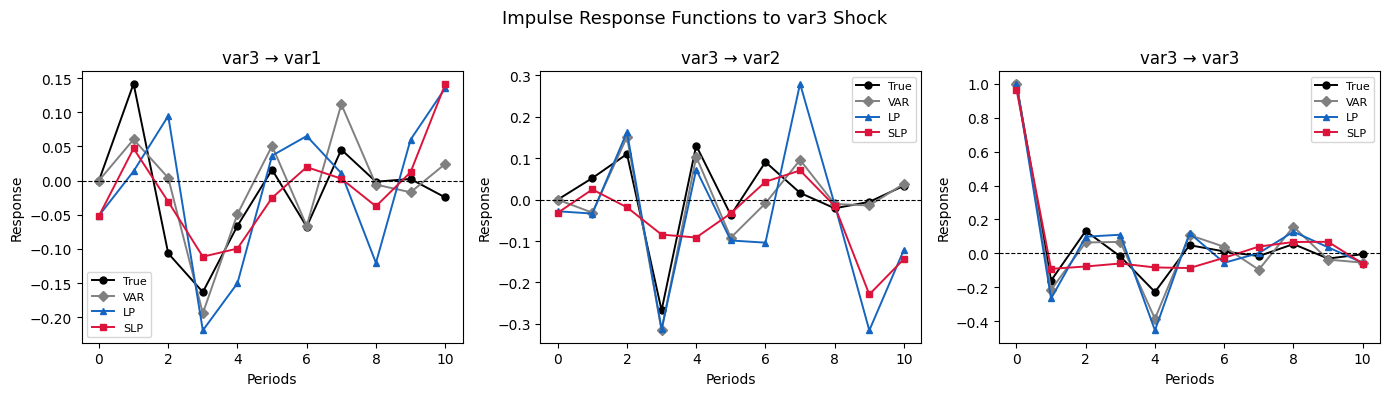

In [28]:
plot_irf_combined(true_irf, var_beta, LP_beta, SLP_beta)

### Discussion
The accuracy of these estimation procedures can be compared by calculating the mean squared error (MSE) of each.

In [8]:
print(f"MSE of VAR IRFs: {np.mean((true_irf.values - var_beta.values)**2)}")
print(f"MSE of LP IRFs: {np.mean((true_irf.values - LP_beta.values)**2)}")
print(f"MSE of SLP IRFs: {np.mean((true_irf.values - SLP_beta.values)**2)}")

MSE of VAR IRFs: 0.005420287437090784
MSE of LP IRFs: 0.01580394364430492
MSE of SLP IRFs: 0.020508591034778305


As expected based on the plots, the VAR estimated IRF is closest to the true IRF. In order to ensure that this result is not due to the specific pattern of shocks and coefficients drawn the procedure should be average over multiple iterations.

In [9]:
# calculating the average mean squared error (MSE) over 500 simulations
num = 500
var_MSE = np.zeros(num)
LP_MSE = np.zeros(num)
SLP_MSE = np.zeros(num)

for i in range(num):
    observed_data, A = VAR_data(V,O,T)
    true_irf = true(V,O,q,A)
    
    var_mod = VAR(observed_data)
    results = var_mod.fit(O)
    var_irfs = results.irf(periods=q).irfs
    var_beta = pd.DataFrame(var_irfs[:,:,2])

    LP_mod = SmoothLocalProjections(observed_data, "var3", None, True, O, q)
    LP_beta = pd.DataFrame(LP_mod.LP().beta)
    SLP_beta = pd.DataFrame(LP_mod.SLP().beta)

    var_MSE[i] = np.mean((true_irf.values - var_beta.values)**2)
    LP_MSE[i] = np.mean((true_irf.values - LP_beta.values)**2)
    SLP_MSE[i] = np.mean((true_irf.values - SLP_beta.values)**2)

avg_var_MSE = np.mean(var_MSE)
avg_LP_MSE = np.mean(LP_MSE)
avg_SLP_MSE = np.mean(SLP_MSE)

print(f"Average MSE of VAR IRFs over {num} simulations: {avg_var_MSE:.5f}")
print(f"Average MSE of LP IRFs over {num} simulations: {avg_LP_MSE:.5f}")
print(f"Average MSE of SLP IRFs over {num} simulations: {avg_SLP_MSE:.5f}")

Average MSE of VAR IRFs over 500 simulations: 0.00609
Average MSE of LP IRFs over 500 simulations: 0.01587
Average MSE of SLP IRFs over 500 simulations: 0.01342


From the above calculations it is clear that VARs have an advantage over LPs and SLPs when the underlying DGP follows a vector autoregressive process. Examining the plots suggests that a weakness of SLPs is failing to capture the jaggedness and lack of simultaneity in the underlying process, while in the case of var2 failing to capture the eventual dissipation of the shock.

Also of interest is how SLP accuracy changes as a function of the smoothing parameter $\lambda$. The default value is $\lambda = 1$.

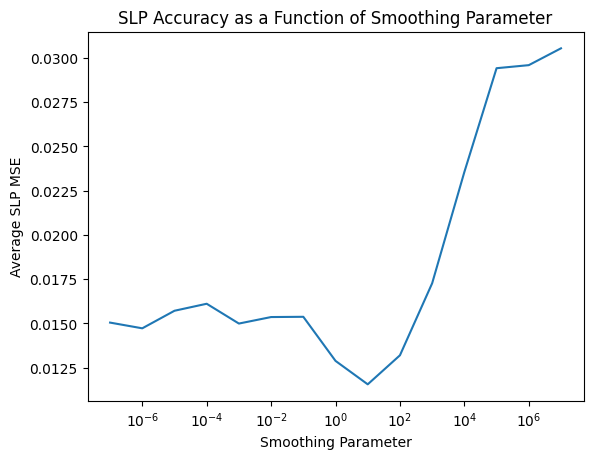

In [10]:
# evaluating how SLP MSE changes with smoothing parameter
num = 100
rng = 15
SLP_MSE_lam = np.zeros((rng,2))

for i in range(rng):
    SLP_MSE = np.zeros(num)
    lam = 10**(i-7)

    for j in range(num):
        observed_data, A = VAR_data(V,O,T)
        true_irf = true(V,O,q,A)

        LP_mod = SmoothLocalProjections(observed_data, "var3", None, True, O, q)
        SLP_beta = pd.DataFrame(LP_mod.SLP(lam = lam).beta) # test smoothing parameter values between 10^-7 and 10^7

        SLP_MSE[j] = np.mean((true_irf.values - SLP_beta.values)**2)

    SLP_MSE_lam[i,0] = np.mean(SLP_MSE)
    SLP_MSE_lam[i,1] = lam

SLP_MSE_lam = pd.DataFrame(SLP_MSE_lam)

plt.plot(SLP_MSE_lam[1], SLP_MSE_lam[0])
plt.xlabel("Smoothing Parameter")
plt.ylabel("Average SLP MSE")
plt.title("SLP Accuracy as a Function of Smoothing Parameter")
plt.xscale('log')
plt.show()

The SLP MSE appears to have a local minimum between $\lambda = 1$ and $\lambda = 100$, and sharply increases for higher values. Even in this optimal range the SLP estimates are much less accurate than VAR estimates.

It is also important to consider sensitivity to misspecification in estimated lag structure. 

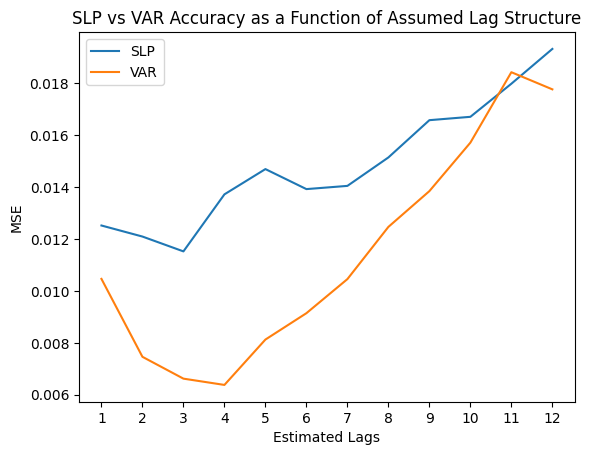

In [11]:
# Evaluating sensitivity to assumed lag structure
num = 100
rng = 12
MSE_diff = np.zeros((rng,3))

for i in range(rng):
    lags = i+1 # sigma_obs from 0.0125 to 0.25 in 0.0125 increments
    var_MSE = np.zeros(num)
    SLP_MSE = np.zeros(num)

    for j in range(num):
        observed_data, A = VAR_data(V,O,T)
        true_irf = true(V,O,q,A)
    
        var_mod = VAR(observed_data)
        var_fit = var_mod.fit(lags)
        var_irfs = var_fit.irf(periods=q).irfs
        var_beta = pd.DataFrame(var_irfs[:,:,2])

        LP_mod = SmoothLocalProjections(observed_data, "var3", None, True, lags, q)
        SLP_beta = pd.DataFrame(LP_mod.SLP().beta)

        var_MSE[j] = np.mean((true_irf.values - var_beta.values)**2)
        SLP_MSE[j] = np.mean((true_irf.values - SLP_beta.values)**2)

    MSE_diff[i,0] = np.mean(SLP_MSE)
    MSE_diff[i,1] = np.mean(var_MSE)
    MSE_diff[i,2] = lags

MSE_diff = pd.DataFrame(MSE_diff)

plt.plot(MSE_diff[2], MSE_diff.drop(columns=2))
plt.xlabel("Estimated Lags")
plt.ylabel("MSE")
plt.title("SLP vs VAR Accuracy as a Function of Assumed Lag Structure")
plt.legend(["SLP", "VAR"])
plt.xticks(MSE_diff[2])
plt.show()

While less accurate than VAR for all measured lag structures, SLP estimates appear to be less sensitive to incorrect specification. SLP inaccuracy increases at a slower rate than with VAR estimates, and their MSE appears to converge at high numbers of lags.